In [14]:
from accelforge import Spec, examples
from pathlib import Path

In [15]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

# Decode Baseline

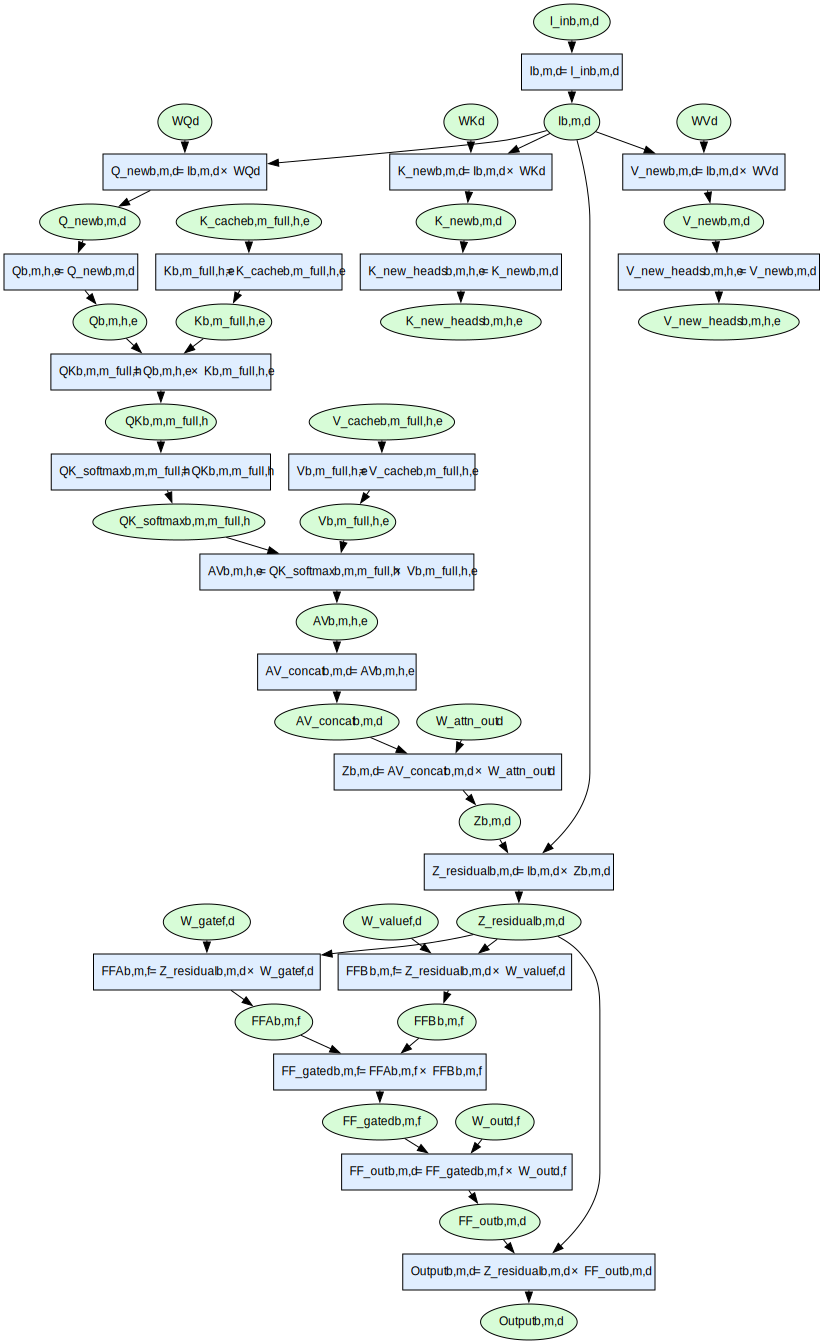

In [16]:
# Load architecture, workload, and mapping
spec = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../gpu_scripts/decode_workload.yaml"
)
spec.workload

In [17]:
# Run analysis
results = spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running Output:
Generating pmapping templates for compute ScalarUnit Einsum I: 2it [00:00, 49.97it/s]?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V_new_heads: 2it [00:00, 61.28it/s]
Generating pmapping templates for compute MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K: 2it [00:00, 37.39it/s]
Generating pmapping templates for compute MAC Einsum V_new_heads: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q: 5it [00:00, 30.46it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K_new_heads: 2it

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum Q_new has 92 pmapping jobs:
	0	[WQ in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  [Q_new in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  [I in LocalBuffer] [Q_new in LocalBuffer] [WQ in Register] T-b  T-m  MAC computes Q_new
	1	[WQ in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  [Q_new in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  [Q_new in LocalBuffer] [I in LocalBuffer] [WQ in Register] T-b  T-m  MAC computes Q_new
	2	[WQ in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  [Q_new in GlobalBuffer] T-d  [WQ in GlobalBuffer] T-b  T-m  S-Z-m  S-Z-d  S-Z-b  [I in LocalBuffer] [Q_new in LocalBuffer] [WQ in Register] T-b  T-m  MAC computes Q_new
	3	[WQ in MainMemory] T-b  T-d  T-m  

Generating pmappings:  67%|█████▎  | 948/1414 [02:26<00:12, 37.22it/s]

ValueError: No backing TensorHolder found in mapping T-b in [0..n_iterations<SEP>0) tile_shape=1, T-m in [0..n_iterations<SEP>1) tile_shape=1, [AV in GlobalBuffer], AV reserves GlobalBuffer, T-b in [0..n_iterations<SEP>2) tile_shape=1, T-e in [0..n_iterations<SEP>3) tile_shape=stride3, T-h in [0..n_iterations<SEP>4) tile_shape=stride4, T-m in [0..n_iterations<SEP>5) tile_shape=1, T-b in [0..n_iterations<SEP>6) tile_shape=1, T-d in [0..n_iterations<SEP>7) tile_shape=stride7, T-e in [0..n_iterations<SEP>8) tile_shape=stride8, T-h in [0..n_iterations<SEP>9) tile_shape=stride9, T-m in [0..n_iterations<SEP>10) tile_shape=1, S-Z-m in [0..n_iterations<SEP>11) tile_shape=1, S-Z-h in [0..n_iterations<SEP>12) tile_shape=1, S-Z-e in [0..n_iterations<SEP>13) tile_shape=1, S-Z-d in [0..n_iterations<SEP>14) tile_shape=1, S-Z-b in [0..n_iterations<SEP>15) tile_shape=1, ScalarUnit computes AV_concat

Generating pmappings:  68%|█████▍  | 955/1414 [02:43<00:12, 37.22it/s]